In [18]:
from torchvision import datasets
from torch.utils.data import DataLoader
import torch
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from typing import Tuple
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [2]:
# Проверяем наличие CUDA
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Используется GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA не найдена, используется CPU")

Используется GPU: NVIDIA GeForce RTX 3060


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.462786465883255, 0.40768909454345703, 0.3523498475551605],
        std=[0.21254687011241913, 0.19136549532413483, 0.22076259553432465]
    )
])

train_dataset = datasets.ImageFolder(root='data/data/train', transform=transform)
test_dataset = datasets.ImageFolder(root='data/data/test', transform=transform)

classes = train_dataset.classes


train_loader = DataLoader(dataset=train_dataset, batch_size=256, shuffle=True, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=256, shuffle=False, pin_memory=True)



In [4]:

# mean = torch.zeros(3)
# std = torch.zeros(3)
# total = 0

# for images, labels in train_loader :
#     batch_samples = images.size(0)
#     images = images.view(batch_samples, 3, -1)

#     mean += images.mean(2).sum(0)
#     std += images.std(2).sum(0)
#     total += batch_samples

# mean /= total
# std /= total

# print(f"Mean: {mean.tolist()}")
# print(f"Std:  {std.tolist()}")


In [5]:
class SimpsonModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.seq = nn.Sequential(

            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 20),

        )
        
    def forward(self, x):
        return self.seq(x)


In [6]:
criterion = nn.CrossEntropyLoss()
model =  SimpsonModel().to(device)
opt = optim.Adam(model.parameters())

In [7]:
def train_step() -> float:
    model.train()
    
    running_loss = 0.
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Удаляем накопленные ранее градиенты.
        # parameter.grad = 0
        opt.zero_grad()
        
        # Делаем проход (forward pass).
        # Состояние модели `train` обеспечивает сохранение промежуточных результатов вычислений.
        # Эти сохраненные значения будут использованы ниже для вычисления градиента функции потерь.
        output = model(images)
        
        # Вычисляем функцию потерь на основе предсказания модели.
        loss = criterion(output, labels)

        # Вычисляем градиент: направление, в котором функция потерь возрастает максимально быстро.
        # parameter.grad += dloss / dparameter
        loss.backward()

        # parameter += -lr * parameter.grad
        # 
        # PyTorch SGD:
        # velocity = momentum * velocity + parameter.grad
        # parameter += - lr * velocity
        opt.step()
        
        # Накапливаем статистику.
        running_loss += loss
    
    # Контекстный менеджер `torch.no_grad` позволяет отключить вычисление градиентов.
    # Вычисления, в которые входят обучаемые параметры, не имеющие отношения к сети повлияют на процесс обучения,
    # если для них будут накапливаться градиенты.
    # Экономия памяти.
    with torch.no_grad():
        train_loss = running_loss / len(train_loader)
    return train_loss.item()


def test_step() -> Tuple[float, float]:
    model.eval()

    correct_total = 0.
    running_loss = 0.
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)
            
            prediction = output.max(  # [bs, num_classes] -> [bs, 1]
                dim=1,
                keepdim=True,
            )[1]
            correct_total += prediction.eq(labels.view_as(prediction)).sum()
            
            loss = criterion(output, labels)
            running_loss += loss
        
    valid_loss = running_loss / len(test_loader)
    accuracy = correct_total / len(test_loader.dataset)
    return valid_loss.item(), accuracy.item()

In [8]:
train_losses = []
valid_losses = []
valid_accs = []

In [9]:
epochs = 20
model.to(device)

for _ in (pbar := tqdm(range(epochs))):
    train_loss = train_step()
    valid_loss, valid_acc = test_step()
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)
    
    pbar.set_description(f'Avg. train/valid loss/valid acc: {train_loss:.4f}/{valid_loss:.4f}/{valid_acc:.4f}')

Avg. train/valid loss/valid acc: 0.0892/0.1367/0.9566: 100%|██████████| 20/20 [19:22<00:00, 58.12s/it]


Text(0, 0.5, 'Loss')

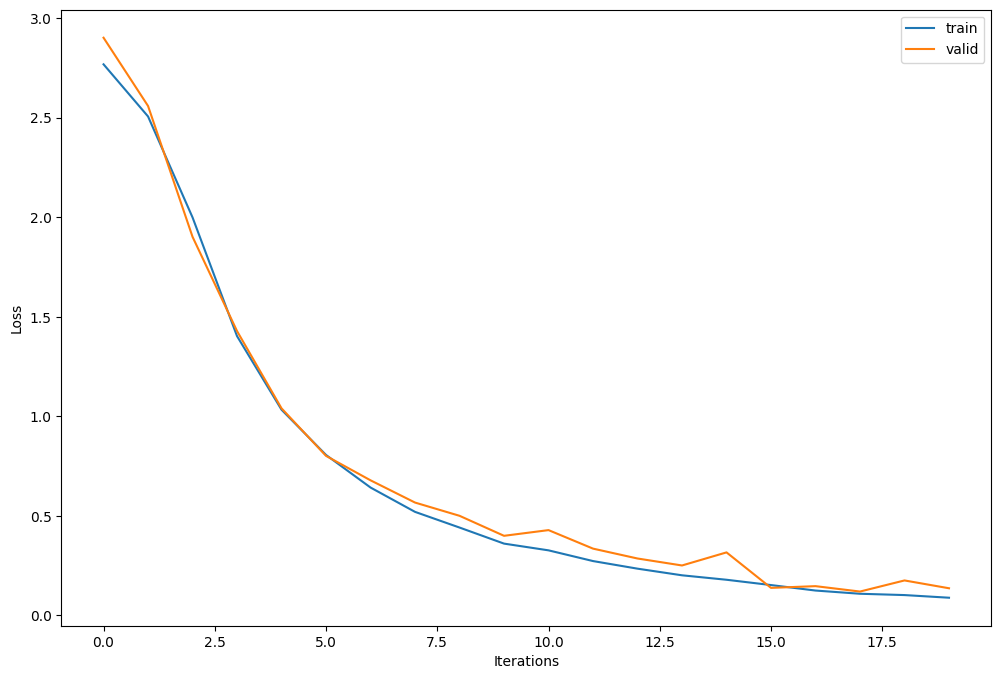

In [16]:
fig = plt.figure(figsize=(12, 8))

plt.plot(train_losses, label='train')
plt.plot(valid_losses, label='valid')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

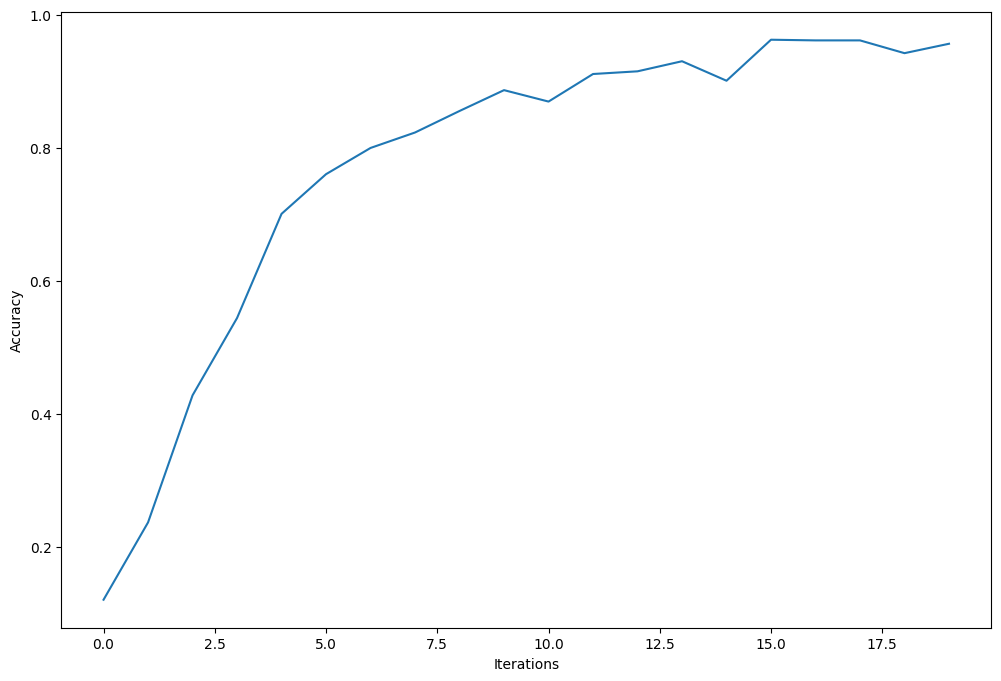

In [17]:
fig = plt.figure(figsize=(12, 8))

plt.plot(valid_accs)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')

In [23]:
def visualize_classification(model, dataloader, classes, device, num_images=12, threshold=0.5):

    model.eval()
    
    # Получаем один батч данных
    images_batch, labels_batch = next(iter(dataloader))
    
    # Ограничиваем количество изображений размером батча
    num_images = min(num_images, len(images_batch))
    
    indices = torch.randint(0, len(images_batch), (num_images,))

    images_batch = images_batch[indices].to(device)
    labels_batch = labels_batch[indices].to(device)
    
    mean = np.array([0.462786465883255, 0.40768909454345703, 0.3523498475551605])
    std = np.array([0.21254687011241913, 0.19136549532413483, 0.22076259553432465])
    
    with torch.no_grad():
        outputs = model(images_batch)
        _, predictions = torch.max(outputs, 1)
    
    cols = 4
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    
    if num_images == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i in range(num_images):
        img = images_batch[i].cpu().permute(1, 2, 0).numpy()
        
        # Обратная нормализация (чтобы цвета были естественными)
        img = img * std + mean
        img = np.clip(img, 0, 1) # Ограничиваем значения от 0 до 1
        
        true_label_idx = labels_batch[i].item()
        pred_label_idx = predictions[i].item()
        
        true_class_name = classes[true_label_idx]
        pred_class_name = classes[pred_label_idx]
        
        is_correct = (true_label_idx == pred_label_idx)
        color = 'green' if is_correct else 'red'
        status = 'YES YES YES' if is_correct else 'NO NO NO'
        
        axes[i].imshow(img)
        axes[i].axis('off')
        
        # Заголовок с информацией
        title = (f'True: {true_class_name}\n'
                 f'Pred: {pred_class_name}\n'
                 f'{status}')
        
        axes[i].set_title(title, fontsize=12, color=color, pad=10)
    
    # Скрываем пустые подграфики, если num_images не кратно cols
    for j in range(num_images, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'Classification Results (Correct: {sum(predictions == labels_batch)}/{num_images})', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [13]:
torch.save(
    obj=model.state_dict(),
    f='weights.pt',
)

In [14]:
model = SimpsonModel()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(
    torch.load('weights.pt', map_location=device, weights_only=True)
)

model = model.to(device)

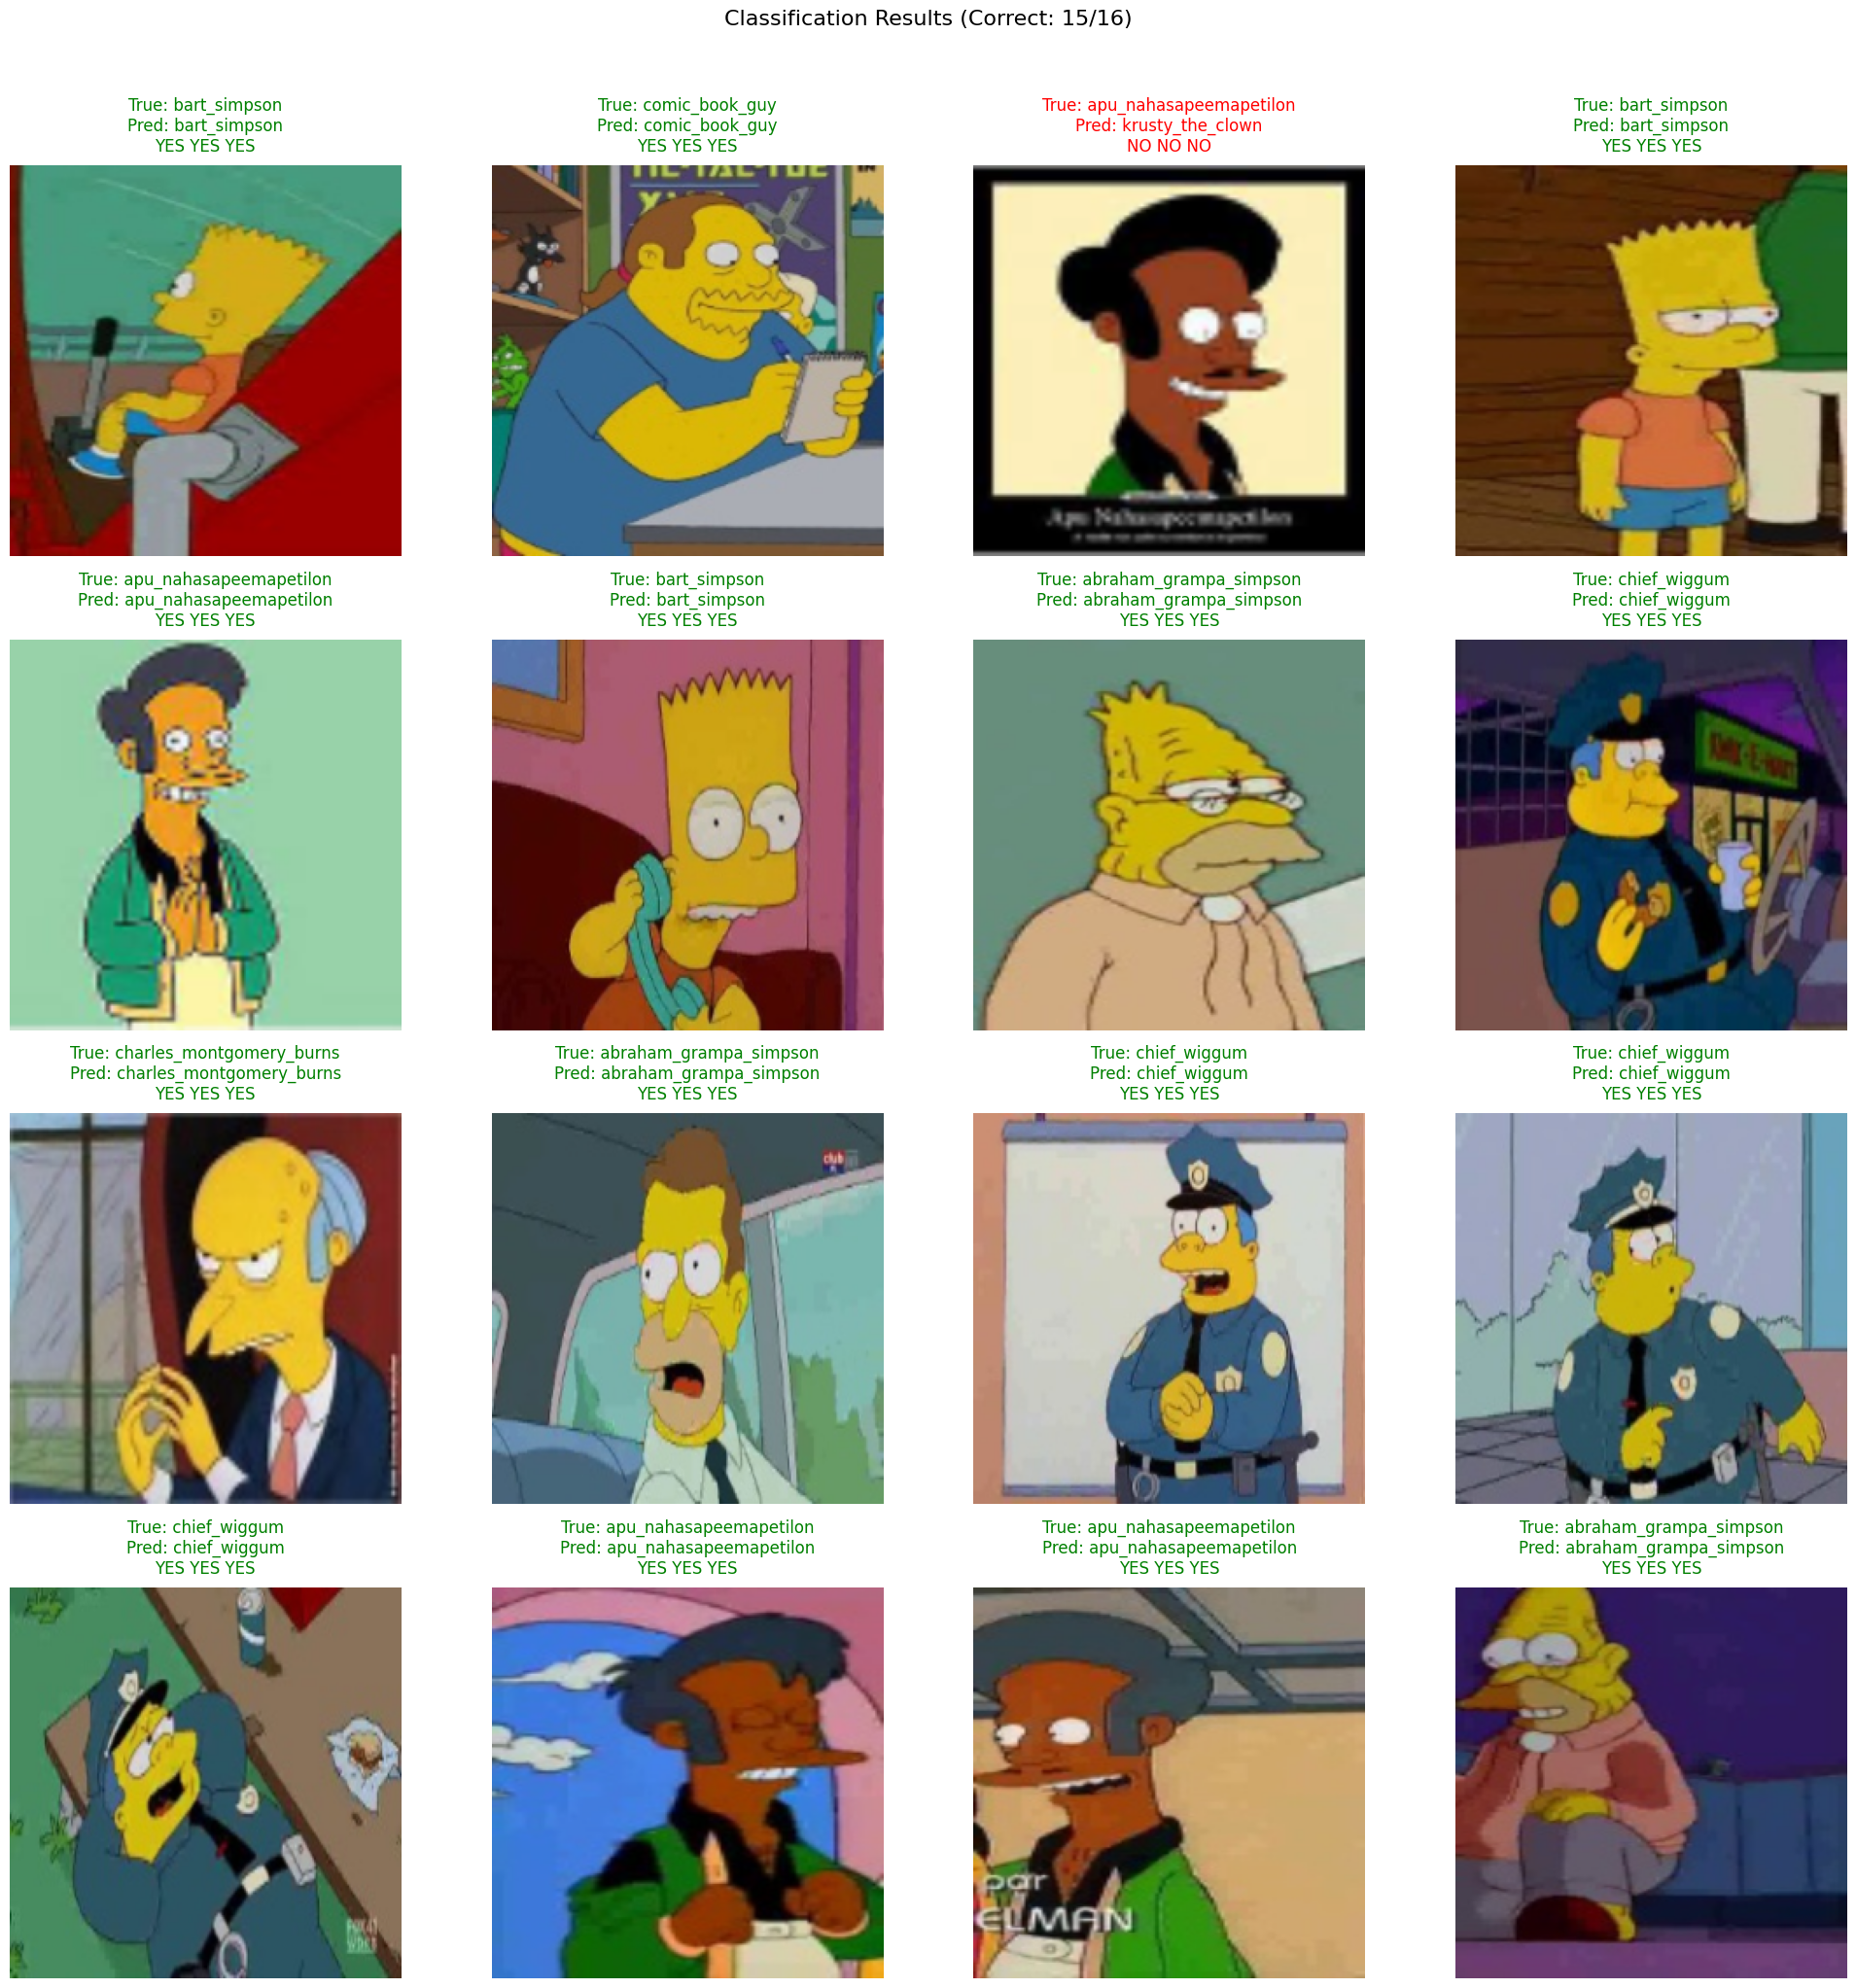

In [28]:
visualize_classification(
    model=model, 
    dataloader=test_loader, 
    classes=classes,
    device=device, 
    num_images=16
)